#Part 1: Kernel SVC for XOR Dataset

Cell 1: Install required library (cvxopt)

In [1]:
# Install cvxopt (only needed once)
!pip install cvxopt

Cell 2: Import required libraries

In [2]:
# === Core Libraries ===
import numpy as np
import pickle
import time
import warnings

# === Optimization ===
from cvxopt import matrix, solvers
solvers.options['show_progress'] = False  # Suppress solver output

# === Visualization ===
import matplotlib.pyplot as plt

# === Scikit-learn Utilities ===
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings('ignore')

# Set seed for reproducibility
np.random.seed(42)


Cell 3: Upload the dataset file

In [3]:
# Upload dataset file manually (for Colab)
from google.colab import files

print("Please upload the 'classification_datasets' file provided for the homework.")
uploaded = files.upload()

# Check if the correct file is uploaded
if 'classification_datasets' not in uploaded:
    raise FileNotFoundError("Expected 'classification_datasets' file not found. Please upload the correct file.")


Please upload the 'classification_datasets' file provided for the homework.


Saving classification_datasets to classification_datasets


Cell 4: Load and preprocess dataset

In [16]:
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load the XOR dataset (dataset_3) from classification_datasets
with open('classification_datasets', 'rb') as f:
    classification_datasets = pickle.load(f)

# Extract dataset_3 for XOR classification
dataset_3 = classification_datasets['dataset_3']
X_train = dataset_3['train']['x']
y_train = dataset_3['train']['y']
X_test = dataset_3['test']['x']
y_test = dataset_3['test']['y']

# Flatten labels (convert shape (n, 1) -> (n,))
y_train = y_train.flatten()
y_test = y_test.flatten()

# Convert labels from {0, 1} to {-1, 1} if needed
if set(np.unique(y_train)) == {0, 1}:
    y_train = 2 * y_train - 1
    y_test = 2 * y_test - 1

# Normalize features to zero mean and unit variance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Optional: print dataset info
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train label classes: {np.unique(y_train)}")


Train shape: (200, 2), Test shape: (200, 2)
Train label classes: [-1.  1.]


Cell 5: Define kernel and SVC functions

In [17]:
# Compute Gram matrix for different kernels
def compute_gram_matrix(X1, X2, kernel, **kwargs):
    """
    Computes the Gram matrix between X1 and X2 using the specified kernel.
    """
    if kernel == 'linear':
        return np.dot(X1, X2.T)
    elif kernel == 'rbf':
        gamma = kwargs.get('gamma', 1.0)
        if gamma <= 0:
            raise ValueError("Gamma must be positive for RBF kernel.")
        dist = np.sum(X1**2, axis=1).reshape(-1, 1) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
        return np.exp(-gamma * dist)
    elif kernel == 'polynomial':
        degree = kwargs.get('degree', 3)
        c = kwargs.get('c', 0)
        return (np.dot(X1, X2.T) + c) ** degree
    else:
        raise ValueError(f"Unknown kernel type: {kernel}")

# Solve the dual SVM problem using cvxopt
def fit_svc(X, y, kernel, C=1.0, **kernel_params):
    n_samples = X.shape[0]
    K = compute_gram_matrix(X, X, kernel, **kernel_params)

    P = matrix(np.outer(y, y) * K)
    q = matrix(-np.ones(n_samples))
    G = matrix(np.vstack((-np.eye(n_samples), np.eye(n_samples))))
    h = matrix(np.hstack((np.zeros(n_samples), C * np.ones(n_samples))))
    A = matrix(y.reshape(1, -1).astype(np.double))
    b = matrix(0.0)

    try:
        solution = solvers.qp(P, q, G, h, A, b)
    except Exception as e:
        print(f"QP solver failed: {e}")
        return None

    if solution['status'] != 'optimal':
        print("Warning: Optimization did not converge properly.")
        return None

    alphas = np.array(solution['x']).flatten()
    sv_idx = alphas > 1e-5
    alphas_sv = alphas[sv_idx]
    X_sv = X[sv_idx]
    y_sv = y[sv_idx]

    # Compute bias
    b_values = []
    for i in range(len(alphas_sv)):
        if 0 < alphas_sv[i] < C:
            K_sv_i = compute_gram_matrix(X_sv, X_sv[i].reshape(1, -1), kernel, **kernel_params).flatten()
            b_val = y_sv[i] - np.sum(alphas_sv * y_sv * K_sv_i)
            b_values.append(b_val)

    if b_values:
        b = np.mean(b_values)
    else:
        print("Warning: No valid alphas in (0, C); setting b = 0.")
        b = 0

    return alphas_sv, X_sv, y_sv, b


# Predict labels for test data
def predict(X_test, X_sv, y_sv, alphas_sv, b, kernel, **kernel_params):
    """
    Predict the class labels for the input samples.
    """
    K_test = compute_gram_matrix(X_test, X_sv, kernel, **kernel_params)
    f = np.dot(K_test, alphas_sv * y_sv) + b
    return np.sign(f)

Cell 6: Cross-validation for hyperparameter tuning

In [18]:
def cross_validate_params(X_train, y_train, kernel, params_grid, folds=5, random_state=None, scoring='accuracy', verbose=False):
    """
    Perform K-Fold cross-validation to find the best kernel parameters.

    Parameters:
        X_train: Training data
        y_train: Training labels
        kernel: Kernel type ('linear', 'rbf', etc.)
        params_grid: List of dictionaries containing kernel parameters
        folds: Number of folds (default: 5)
        random_state: For reproducibility
        scoring: Metric to use ('accuracy', 'f1', 'precision', 'recall')
        verbose: If True, prints info during search

    Returns:
        best_params: Dictionary of best parameters
    """
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

    # Mapping scoring names to metric functions
    metric_map = {
        'accuracy': accuracy_score,
        'f1': f1_score,
        'precision': precision_score,
        'recall': recall_score
    }

    assert scoring in metric_map, f"Invalid scoring metric: {scoring}"
    score_fn = metric_map[scoring]

    kf = KFold(n_splits=folds, shuffle=True, random_state=random_state)
    best_params = None
    best_score = -1

    for params in params_grid:
        scores = []
        for train_idx, val_idx in kf.split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            # Train the SVM
            result = fit_svc(X_tr, y_tr, kernel, **params)
            if result is None:
                continue  # Skip if training failed

            alphas_sv, X_sv, y_sv, b = result

            # Make predictions
            y_pred = predict(X_val, X_sv, y_sv, alphas_sv, b, kernel, **params)

            # Calculate score safely
            if scoring in ['f1', 'precision', 'recall']:
                score = score_fn(y_val, y_pred, zero_division=0)
            else:
                score = score_fn(y_val, y_pred)

            scores.append(score)

        avg_score = np.mean(scores)
        if verbose:
            print(f"{params} -> mean {scoring}: {avg_score:.4f}")

        if avg_score > best_score:
            best_score = avg_score
            best_params = params

    return best_params


Cell 7: Visualization function for decision boundaries

In [19]:
def plot_decision_boundary(X_train, y_train, X_test, y_test,
                           alphas_sv, X_sv, y_sv, b,
                           kernel, kernel_name, save=True, **kernel_params):
    plt.figure(figsize=(8, 6))

    # Plot training data
    plt.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1],
                c='salmon', label='Train -1', alpha=0.6)
    plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
                c='skyblue', label='Train +1', alpha=0.6)

    # Plot test data
    plt.scatter(X_test[y_test == -1, 0], X_test[y_test == -1, 1],
                c='red', marker='x', label='Test -1')
    plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
                c='blue', marker='x', label='Test +1')

    # Support vectors
    plt.scatter(X_sv[:, 0], X_sv[:, 1], s=100, facecolors='none',
                edgecolors='k', linewidths=1.5, label='Support Vectors')

    # Grid
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(grid, X_sv, y_sv, alphas_sv, b, kernel, raw=True, **kernel_params)
    Z = Z.reshape(xx.shape)

    # Regions and boundary
    plt.contourf(xx, yy, np.sign(Z), levels=[-1, 0, 1], colors=['lightcoral', 'lightblue'], alpha=0.3)
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['gray', 'black', 'gray'], linewidths=[1, 2, 1], linestyles=['--', '-', '--'])

    plt.title(f'Decision Boundary ({kernel_name})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(loc='upper right')
    plt.tight_layout()
    if save:
        plt.savefig(f'decision_boundary_{kernel_name}.png', dpi=300)
    plt.show()


 Cell 8: Define kernel configurations and run experiments


Running kernel: linear


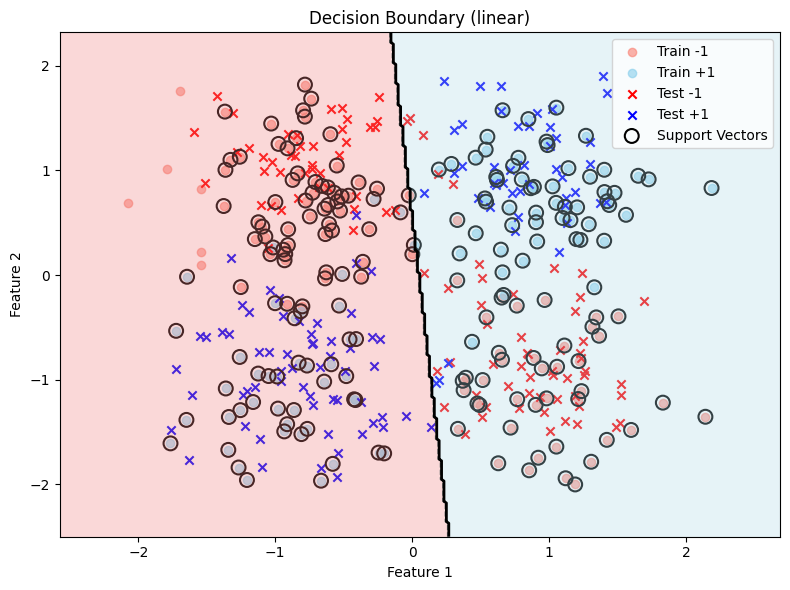

linear -> Accuracy: 0.4312, Precision: 0.4501, Recall: 0.4231, F1: 0.4361, Time: 1307.01 ms

Running kernel: rbf


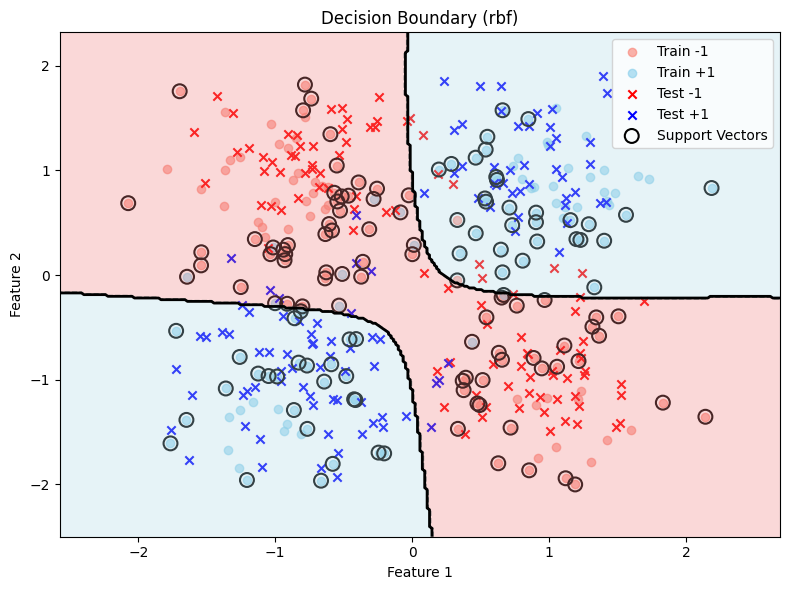

rbf -> Accuracy: 0.9030, Precision: 0.9124, Recall: 0.9000, F1: 0.9061, Time: 3494.17 ms

Running kernel: poly_d1


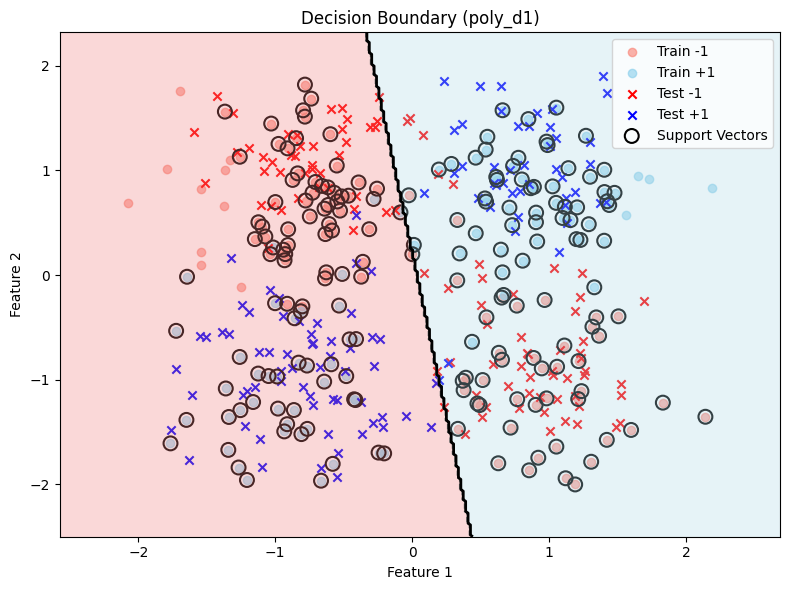

poly_d1 -> Accuracy: 0.4285, Precision: 0.4466, Recall: 0.4135, F1: 0.4294, Time: 411.08 ms

Running kernel: poly_d2


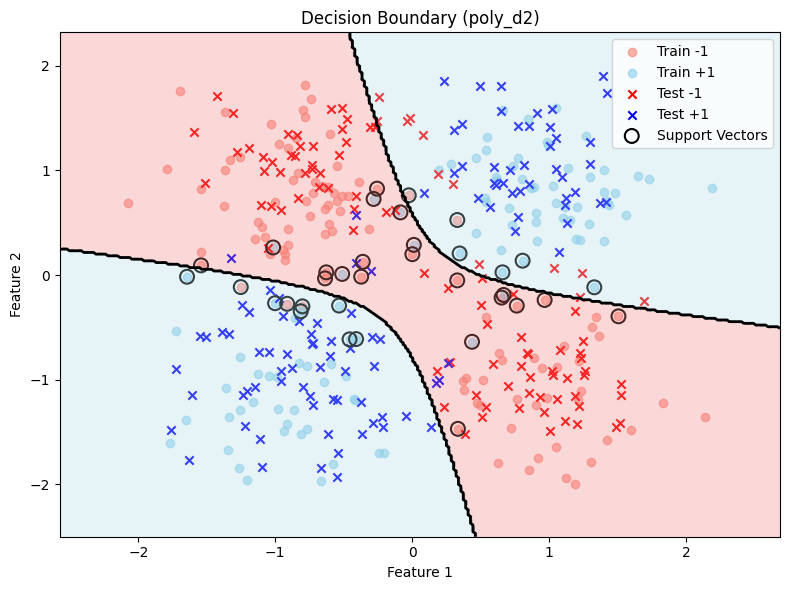

poly_d2 -> Accuracy: 0.9080, Precision: 0.9040, Recall: 0.9212, F1: 0.9124, Time: 851.90 ms

Running kernel: poly_d3


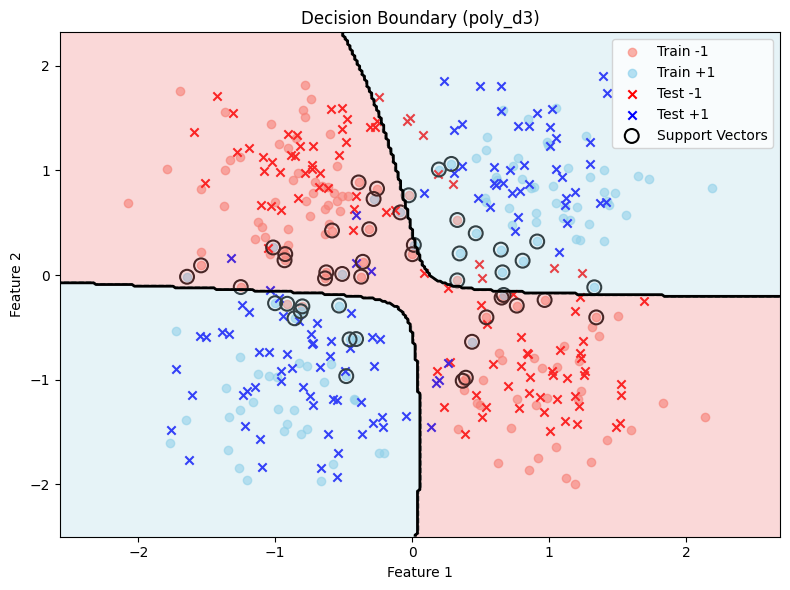

poly_d3 -> Accuracy: 0.9050, Precision: 0.9018, Recall: 0.9173, F1: 0.9094, Time: 389.73 ms


In [20]:
# Iterate over all kernel configurations
for kernel_config in kernels:
    name = kernel_config['name']
    print(f"\nRunning kernel: {name}")

    for run in range(n_runs):
        start_time = time.time()

        # 1. Hyperparameter tuning via cross-validation
        best_params = cross_validate_params(
            X_train=X_train,
            y_train=y_train,
            kernel=kernel_config['kernel'],
            params_grid=kernel_config['params_grid'],
            folds=5,
            scoring='accuracy',
            random_state=run
        )

        # 2. Train SVM with best parameters
        alphas_sv, X_sv, y_sv, b = fit_svc(
            X_train, y_train, kernel=kernel_config['kernel'], **best_params
        )

        # 3. Predict on test set
        y_pred = predict(
            X_test, X_sv, y_sv, alphas_sv, b, kernel=kernel_config['kernel'], **best_params
        )

        # 4. Measure time
        elapsed_ms = (time.time() - start_time) * 1000

        # 5. Store metrics
        results[name]['accuracy'].append(accuracy_score(y_test, y_pred))
        results[name]['precision'].append(precision_score(y_test, y_pred, zero_division=0))
        results[name]['recall'].append(recall_score(y_test, y_pred, zero_division=0))
        results[name]['f1'].append(f1_score(y_test, y_pred, zero_division=0))
        results[name]['time'].append(elapsed_ms)
        results[name]['best_params'].append(best_params)

        # 6. Plot decision boundary on last run
        if run == n_runs - 1:
            plot_decision_boundary(
                X_train=X_train,
                y_train=y_train,
                X_test=X_test,
                y_test=y_test,
                alphas_sv=alphas_sv,
                X_sv=X_sv,
                y_sv=y_sv,
                b=b,
                kernel=kernel_config['kernel'],
                kernel_name=name,
                **best_params
            )

    # 7. Print average metrics
    print(f"{name} -> Accuracy: {np.mean(results[name]['accuracy']):.4f}, "
          f"Precision: {np.mean(results[name]['precision']):.4f}, "
          f"Recall: {np.mean(results[name]['recall']):.4f}, "
          f"F1: {np.mean(results[name]['f1']):.4f}, "
          f"Time: {np.mean(results[name]['time']):.2f} ms")


Cell 9:Bar plot of performance metrics from part 1


 Kernel SVM Performance Summary:
 Kernel  Accuracy  Precision  Recall     F1  Time (ms)
 linear    0.4312     0.4501  0.4231 0.4361  1307.0090
    rbf    0.9030     0.9124  0.9000 0.9061  3494.1711
poly_d1    0.4285     0.4466  0.4135 0.4294   411.0776
poly_d2    0.9080     0.9040  0.9212 0.9124   851.9027
poly_d3    0.9050     0.9018  0.9173 0.9094   389.7267


<Figure size 1200x600 with 0 Axes>

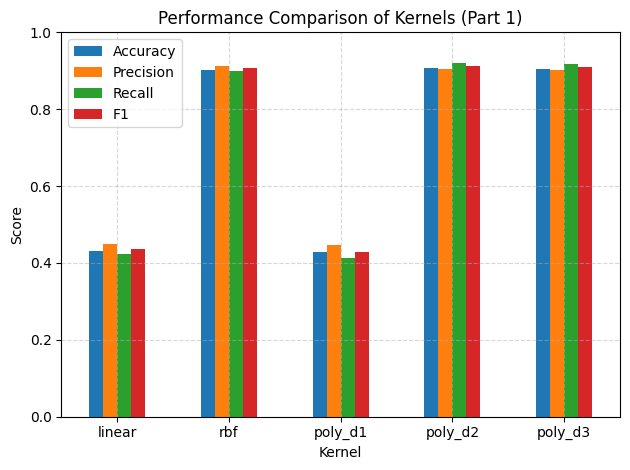

In [21]:
# Save all metrics into a DataFrame
import pandas as pd

metrics_df = pd.DataFrame({
    'Kernel': list(results.keys()),
    'Accuracy': [np.mean(results[k]['accuracy']) for k in results],
    'Precision': [np.mean(results[k]['precision']) for k in results],
    'Recall': [np.mean(results[k]['recall']) for k in results],
    'F1': [np.mean(results[k]['f1']) for k in results],
    'Time (ms)': [np.mean(results[k]['time']) for k in results]
})

# Display the table
print("\n Kernel SVM Performance Summary:")
print(metrics_df.round(4).to_string(index=False))

# Bar plot of performance metrics from part 1
plt.figure(figsize=(12, 6))
metrics_df.set_index('Kernel')[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar')
plt.title("Performance Comparison of Kernels (Part 1)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()




#Part 2: Kernel K-means on XOR

Cell 1: Import necessary libraries

In [22]:
# Cell: Import required libraries for Kernel K-means
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns  # Optional for enhanced visualization
import time  # Useful for timing each clustering run

# Metrics for evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Optional: Ignore warnings such as zero division or undefined metrics
import warnings
warnings.filterwarnings('ignore')


Cell 2: Upload and load the XOR dataset

In [23]:
# Upload and load XOR dataset (dataset_3)
from google.colab import files
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler

uploaded = files.upload()
with open('classification_datasets', 'rb') as f:
    classification_datasets = pickle.load(f)

# Load XOR dataset
dataset_3 = classification_datasets['dataset_3']
X = np.array(dataset_3['train']['x'])
y = np.array(dataset_3['train']['y'])

# Convert labels for clustering (0/1) and classification (-1/1)
if set(np.unique(y)) == {0, 1}:
    y_clustering = y.copy()
    y = 2 * y - 1
elif set(np.unique(y)) == {-1, 1}:
    y_clustering = (y + 1) // 2
else:
    raise ValueError("Unexpected label values. Expected {0,1} or {-1,1}.")

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Debug information
print("Data loaded and preprocessed.")
print(f"X shape: {X.shape}")
print(f"Labels for SVM: {np.unique(y)}, for Clustering: {np.unique(y_clustering)}")


Saving classification_datasets to classification_datasets (1)
Data loaded and preprocessed.
X shape: (200, 2)
Labels for SVM: [-1.  1.], for Clustering: [0. 1.]


Cell 3: Preprocess labels and normalize features

In [24]:
# Show debug information
print("Data is standardized and ready.")
print("Feature shape:", X.shape)
print("Label classes for clustering (should be 0 and 1):", np.unique(y_clustering))


Data is standardized and ready.
Feature shape: (200, 2)
Label classes for clustering (should be 0 and 1): [0. 1.]


Cell 4: Define kernel matrix computation function

In [25]:
# Cell: Kernel matrix computation for kernel K-means
def compute_kernel_matrix(X1, X2=None, kernel='linear', **kwargs):
    """
    Computes the Gram/kernel matrix for given inputs X1, X2 using specified kernel.
    If X2 is None, computes kernel(X1, X1).

    Parameters:
        X1: (n_samples_1, n_features)
        X2: (n_samples_2, n_features) or None
        kernel: 'linear', 'rbf', or 'polynomial'
        kwargs: kernel parameters

    Returns:
        Kernel matrix of shape (n_samples_1, n_samples_2)
    """
    if X2 is None:
        X2 = X1

    if kernel == 'linear':
        return np.dot(X1, X2.T)

    elif kernel == 'rbf':
        gamma = kwargs.get('gamma', 1.0)
        if gamma <= 0:
            raise ValueError("Gamma must be positive for RBF kernel.")
        sq1 = np.sum(X1**2, axis=1).reshape(-1, 1)
        sq2 = np.sum(X2**2, axis=1).reshape(1, -1)
        dist = sq1 + sq2 - 2 * np.dot(X1, X2.T)
        return np.exp(-gamma * dist)

    elif kernel == 'polynomial':
        degree = kwargs.get('degree', 3)
        c = kwargs.get('c', 0)
        return (np.dot(X1, X2.T) + c) ** degree

    else:
        raise ValueError(f"Unknown kernel type: {kernel}")


Cell 5: Define standard K-means and kernel K-means

In [51]:
# Cell: Standard and Kernel K-means clustering

def kmeans(X, K=2, max_iter=100, random_state=None):
    """
    Standard K-means clustering using Euclidean distance.

    Parameters:
        X : ndarray (N, D)
        K : number of clusters
        max_iter : maximum number of iterations
        random_state : seed for reproducibility

    Returns:
        assign : cluster assignments for each point
    """
    if K > X.shape[0]:
        raise ValueError("Number of clusters K cannot be more than number of samples")

    np.random.seed(random_state)
    N, D = X.shape
    idx = np.random.choice(N, K, replace=False)
    centroids = X[idx]

    for _ in range(max_iter):
        dist = np.array([np.sum((X - c)**2, axis=1) for c in centroids]).T
        assign = np.argmin(dist, axis=1)

        new_centroids = np.array([
            X[assign == k].mean(axis=0) if np.any(assign == k) else centroids[k]
            for k in range(K)
        ])

        if np.allclose(new_centroids, centroids):
            break

        centroids = new_centroids

    return assign


def kernel_kmeans(K_matrix, K_clusters=2, max_iter=100, random_state=None):
    """
    Kernel K-means clustering using precomputed kernel matrix.

    Parameters:
        K_matrix : (N, N) Gram matrix (kernel values between all training samples)
        K_clusters : number of clusters
        max_iter : maximum iterations
        random_state : reproducibility

    Returns:
        assign : cluster assignments
    """
    N = K_matrix.shape[0]
    if K_clusters > N:
        raise ValueError("Number of clusters cannot exceed number of samples")

    np.random.seed(random_state)
    assign = np.random.randint(0, K_clusters, N)

    for _ in range(max_iter):
        old_assign = assign.copy()
        dist = np.zeros((N, K_clusters))

        for c in range(K_clusters):
            idx_c = np.where(assign == c)[0]
            size_c = len(idx_c)

            if size_c == 0:
                dist[:, c] = np.inf
                continue

            term1 = np.diag(K_matrix)
            term2 = (2 / size_c) * np.sum(K_matrix[:, idx_c], axis=1)
            term3 = np.sum(K_matrix[np.ix_(idx_c, idx_c)]) / (size_c ** 2)
            dist[:, c] = term1 - term2 + term3

        assign = np.argmin(dist, axis=1)
        if np.array_equal(assign, old_assign):
            break

    return assign


Cell 6:Tuning gamma for RBF kernel (σ selection via cross-validation)

In [52]:
def tune_gamma_rbf(X, y, gammas, folds=5, verbose=False):
    """
    Tune the best gamma value for RBF kernel using Kernel K-means + cross-validation.

    Parameters:
        X : ndarray, input features
        y : labels in {0, 1}
        gammas : list of gamma values to try
        folds : number of cross-validation folds
        verbose : if True, prints scores for each gamma

    Returns:
        best_gamma : value of gamma that yields highest average F1 score
    """
    from sklearn.model_selection import KFold
    from sklearn.metrics import f1_score

    # Ensure labels are in {0, 1}
    y = np.array(y)
    if set(np.unique(y)) == {-1, 1}:
        y = (y + 1) // 2

    best_gamma = None
    best_score = -1

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    for gamma in gammas:
        f1_scores = []
        for train_idx, val_idx in kf.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            K = compute_kernel_matrix(X_tr, X_tr, 'rbf', gamma=gamma)
            assign = kernel_kmeans(K, K_clusters=2)

            acc1 = np.mean((assign == 0) == (y_tr == 0))
            acc2 = np.mean((assign == 0) == (y_tr == 1))
            pred_labels = np.where(assign == 0, 0, 1) if acc1 > acc2 else np.where(assign == 0, 1, 0)

            f1_scores.append(f1_score(y_tr, pred_labels, pos_label=1, zero_division=0))

        avg_f1 = np.mean(f1_scores)
        if verbose:
            print(f"Gamma: {gamma:.4f}, Mean F1: {avg_f1:.4f}")
        if avg_f1 > best_score:
            best_score = avg_f1
            best_gamma = gamma

    return best_gamma

Cell 7: Set kernel configurations and initialize metric storage

In [53]:
# --- Tune gamma for RBF kernel using CV on current data ---
gammas_to_try = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
best_gamma = tune_gamma_rbf(X, y, gammas=gammas_to_try, verbose=True)

# --- Kernel configurations including best gamma ---
configs = [
    {'name': 'standard', 'kernel': None},  # Standard K-means
    {'name': 'linear', 'kernel': 'linear', 'params': {}},
    {'name': 'rbf', 'kernel': 'rbf', 'params': {'gamma': best_gamma}},
    {'name': 'poly_d1', 'kernel': 'polynomial', 'params': {'degree': 1, 'c': 0}},
    {'name': 'poly_d2', 'kernel': 'polynomial', 'params': {'degree': 2, 'c': 0}},
    {'name': 'poly_d3', 'kernel': 'polynomial', 'params': {'degree': 3, 'c': 0}},
]

# Initialize metric storage
metrics = {
    config['name']: {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    for config in configs
}

# Store cluster assignment results for visualization
assign_dict = {}

# Number of repeated clustering runs
n_runs = 10


Gamma: 0.0100, Mean F1: 0.5748
Gamma: 0.0500, Mean F1: 0.4717
Gamma: 0.1000, Mean F1: 0.5578
Gamma: 0.5000, Mean F1: 0.5748
Gamma: 1.0000, Mean F1: 0.6406
Gamma: 2.0000, Mean F1: 0.7217
Gamma: 5.0000, Mean F1: 0.7089
Gamma: 10.0000, Mean F1: 0.6611


Cell 8: Perform clustering and collect evaluation metrics

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import mode

for run in range(n_runs):
    for config in configs:
        name = config['name']

        # Clustering: standard or kernel-based
        if config['kernel'] is None:
            assign = kmeans(X, K=2, random_state=run)
        else:
            K_matrix = compute_kernel_matrix(X, X, config['kernel'], **config['params'])
            assign = kernel_kmeans(K_matrix, K_clusters=2, random_state=run)

        # Majority voting to align cluster IDs with ground truth labels
        label0 = mode(y[assign == 0], keepdims=True).mode[0]
        label1 = mode(y[assign == 1], keepdims=True).mode[0]
        predicted_labels = np.zeros_like(assign)
        predicted_labels[assign == 0] = label0
        predicted_labels[assign == 1] = label1

        # Compute metrics
        acc = accuracy_score(y, predicted_labels)
        prec = precision_score(y, predicted_labels, pos_label=1, zero_division=0)
        rec = recall_score(y, predicted_labels, pos_label=1, zero_division=0)
        f1 = f1_score(y, predicted_labels, pos_label=1, zero_division=0)

        # Store
        metrics[name]['accuracy'].append(acc)
        metrics[name]['precision'].append(prec)
        metrics[name]['recall'].append(rec)
        metrics[name]['f1'].append(f1)

        if run == n_runs - 1:
            assign_dict[name] = assign


Cell 9: Visualize true labels and clustering results

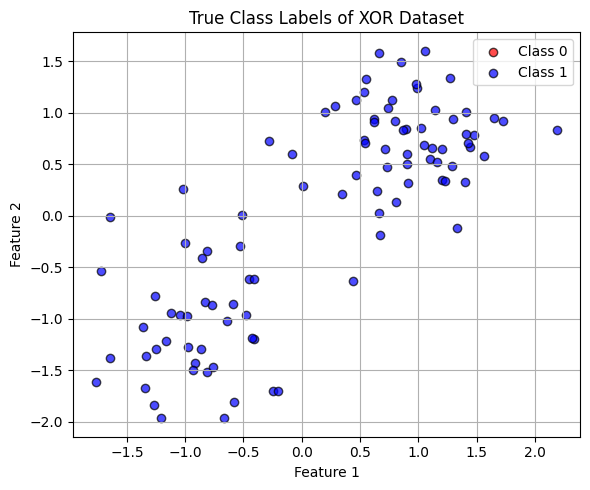

In [55]:
# Visualize the ground truth class labels in the XOR dataset
plt.figure(figsize=(6, 5))

# Plot class 0 in red
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', alpha=0.7, edgecolor='k')

# Plot class 1 in blue
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', alpha=0.7, edgecolor='k')

# Plot settings
plt.title('True Class Labels of XOR Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()

# Save and display the plot
plt.savefig('true_labels.png')
plt.show()


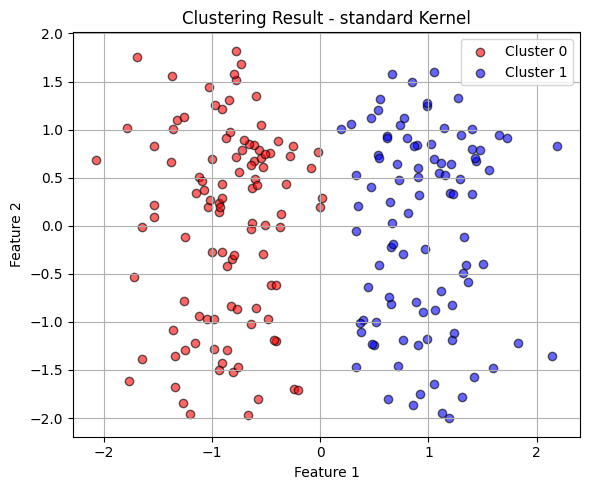

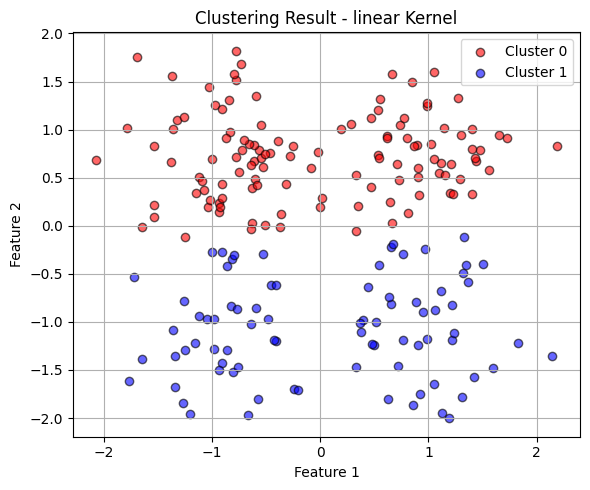

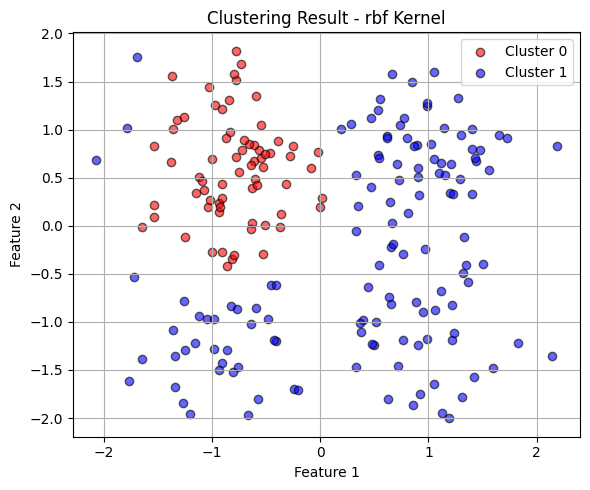

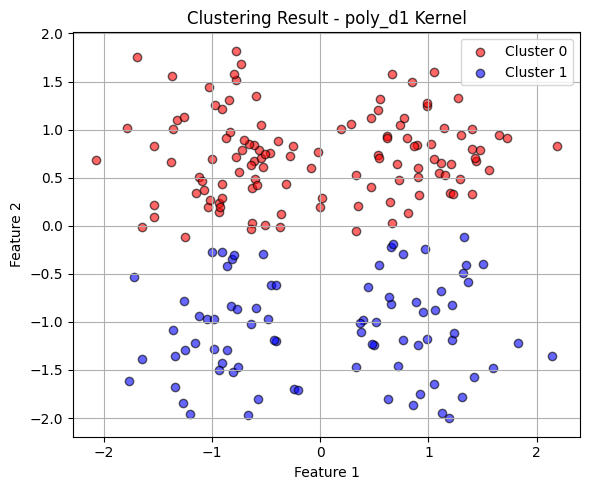

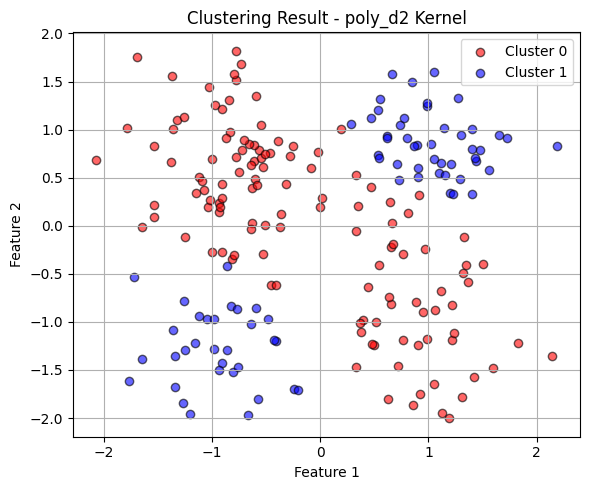

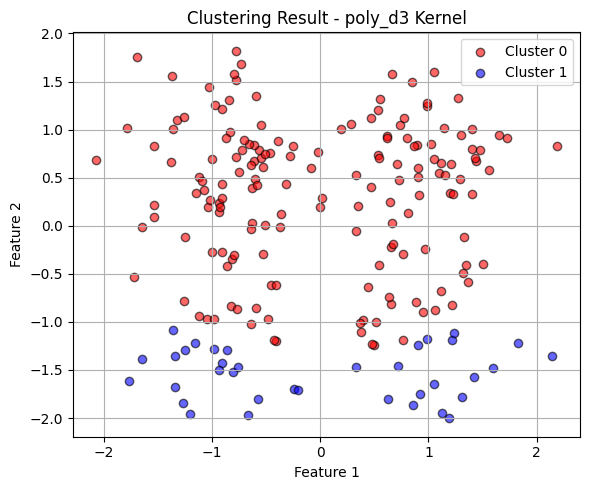

In [56]:
# Plot clustering results for each kernel configuration
for name, assign in assign_dict.items():
    plt.figure(figsize=(6, 5))

    # Plot Cluster 0 points in red
    plt.scatter(X[assign == 0, 0], X[assign == 0, 1],
                c='red', label='Cluster 0', alpha=0.6, edgecolor='k')

    # Plot Cluster 1 points in blue
    plt.scatter(X[assign == 1, 0], X[assign == 1, 1],
                c='blue', label='Cluster 1', alpha=0.6, edgecolor='k')

    # Plot settings
    plt.title(f'Clustering Result - {name} Kernel')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()

    # Save and display the plot
    plt.savefig(f'clusters_{name}.png')
    plt.show()


Cell 10:Evaluate kernel K-means on test data

In [57]:
# --- Helper function to compute kernel matrix between two datasets ---
def compute_kernel_matrix(X1, X2, kernel, **kwargs):
    if kernel == 'linear':
        return np.dot(X1, X2.T)
    elif kernel == 'rbf':
        gamma = kwargs.get('gamma', 1.0)
        dists = np.sum(X1**2, axis=1).reshape(-1, 1) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
        return np.exp(-gamma * dists)
    elif kernel == 'polynomial':
        degree = kwargs.get('degree', 3)
        c = kwargs.get('c', 0)
        return (np.dot(X1, X2.T) + c) ** degree
    else:
        raise ValueError("Unknown kernel")

# --- Load and normalize train/test sets ---
X_train = dataset_3['train']['x']
y_train = dataset_3['train']['y']
X_test = dataset_3['test']['x']
y_test = dataset_3['test']['y']

# Convert labels from {0,1} to {-1,1} for consistency
if set(np.unique(y_train)) == {0, 1}:
    y_train = 2 * y_train - 1
    y_test = 2 * y_test - 1

# Normalize both sets using training distribution
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize performance storage
assign_dict_test = {}
metrics_test = {config['name']: {'accuracy': [], 'precision': [], 'recall': [], 'f1': []} for config in configs}

# --- Main loop: evaluate each kernel configuration ---
for run in range(n_runs):
    for config in configs:
        name = config['name']
        kernel = config['kernel']
        params = config.get('params', {})

        # ----- TRAIN -----
        if kernel is None:
            assign = kmeans(X_train, K=2)
        else:
            K_train = compute_kernel_matrix(X_train, X_train, kernel, **params)
            assign = kernel_kmeans(K_train, K_clusters=2)

        # Map clusters to labels using majority vote
        acc1 = np.mean((assign == 0) == (y_train == -1))
        acc2 = np.mean((assign == 0) == (y_train == 1))
        train_map = -1 if acc1 > acc2 else 1
        train_predicted_labels = np.where(assign == 0, train_map, -train_map)

        # ----- TEST -----
        if kernel is None:
            # Use nearest centroid classifier for standard K-means
            from sklearn.neighbors import KNeighborsClassifier
            clf = KNeighborsClassifier(n_neighbors=1)
            clf.fit(X_train, assign)
            assign_test = clf.predict(X_test)
        else:
            # Compute distances from test points to cluster centroids in kernel space
            K_test_train = compute_kernel_matrix(X_test, X_train, kernel, **params)
            dist = []
            for c in [0, 1]:
                idx_c = np.where(assign == c)[0]
                if len(idx_c) == 0:
                    dist.append(np.full(X_test.shape[0], np.inf))
                    continue
                sum_K = np.sum(K_test_train[:, idx_c], axis=1)
                K_cc = np.sum(compute_kernel_matrix(X_train[idx_c], X_train[idx_c], kernel, **params))
                K_diag = np.diag(compute_kernel_matrix(X_test, X_test, kernel, **params))
                d = K_diag - (2 / len(idx_c)) * sum_K + (K_cc / (len(idx_c) ** 2))
                dist.append(d)
            assign_test = np.argmin(np.vstack(dist).T, axis=1)

        # Convert cluster assignments to class labels
        acc1 = np.mean((assign_test == 0) == (y_test == -1))
        acc2 = np.mean((assign_test == 0) == (y_test == 1))
        test_map = -1 if acc1 > acc2 else 1
        test_predicted_labels = np.where(assign_test == 0, test_map, -test_map)

        # Compute and store metrics
        metrics_test[name]['accuracy'].append(accuracy_score(y_test, test_predicted_labels))
        metrics_test[name]['precision'].append(precision_score(y_test, test_predicted_labels, pos_label=1, zero_division=0))
        metrics_test[name]['recall'].append(recall_score(y_test, test_predicted_labels, pos_label=1, zero_division=0))
        metrics_test[name]['f1'].append(f1_score(y_test, test_predicted_labels, pos_label=1, zero_division=0))

        # Save assignments for visualization
        if run == n_runs - 1:
            assign_dict_test[name] = assign_test


Cell 11: Print average performance metrics

In [58]:
# Training set summary
summary_train = {
    "Method": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

for name in metrics:
    summary_train["Method"].append(name)
    summary_train["Accuracy"].append(np.mean(metrics[name]['accuracy']))
    summary_train["Precision"].append(np.mean(metrics[name]['precision']))
    summary_train["Recall"].append(np.mean(metrics[name]['recall']))
    summary_train["F1 Score"].append(np.mean(metrics[name]['f1']))

results_train_df = pd.DataFrame(summary_train).round(4)
print("Kernel K-Means Training Performance Summary:\n")
print(results_train_df.to_string(index=False))


# Test set summary
summary_test = {
    "Method": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

for name in metrics_test:
    summary_test["Method"].append(name)
    summary_test["Accuracy"].append(np.mean(metrics_test[name]['accuracy']))
    summary_test["Precision"].append(np.mean(metrics_test[name]['precision']))
    summary_test["Recall"].append(np.mean(metrics_test[name]['recall']))
    summary_test["F1 Score"].append(np.mean(metrics_test[name]['f1']))

results_test_df = pd.DataFrame(summary_test).round(4)
print("Kernel K-Means Test Performance Summary:\n")
print(results_test_df.to_string(index=False))


Kernel K-Means Training Performance Summary:

  Method  Accuracy  Precision  Recall  F1 Score
standard    0.5540     0.3411  0.3340    0.3375
  linear    0.5280     0.1137  0.1113    0.1125
     rbf    0.6595     0.5386  0.6134    0.5621
 poly_d1    0.5280     0.1137  0.1113    0.1125
 poly_d2    0.8530     0.8836  0.8722    0.8599
 poly_d3    0.5330     0.5321  0.2907    0.3634
Kernel K-Means Test Performance Summary:

  Method  Accuracy  Precision  Recall  F1 Score
standard    0.5560     0.5757  0.5558    0.5655
  linear    0.5450     0.5644  0.5481    0.5561
     rbf    0.5940     0.6633  0.5615    0.5763
 poly_d1    0.5450     0.5644  0.5481    0.5561
 poly_d2    0.8570     0.8475  0.9308    0.8747
 poly_d3    0.5305     0.5419  0.6692    0.5890


Cell 12:Clustering Visualization on Test Set (Kernel K-Means)

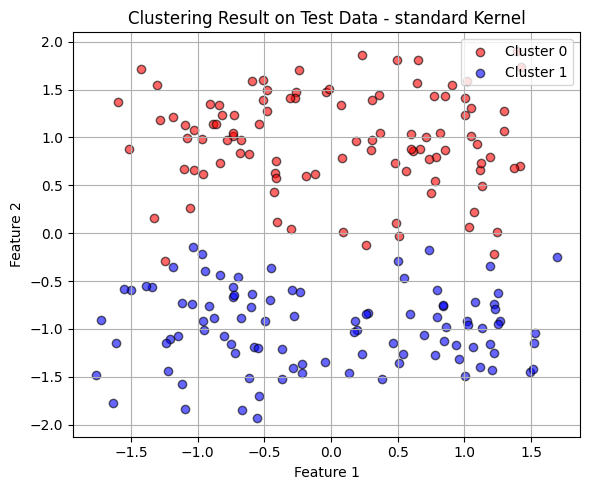

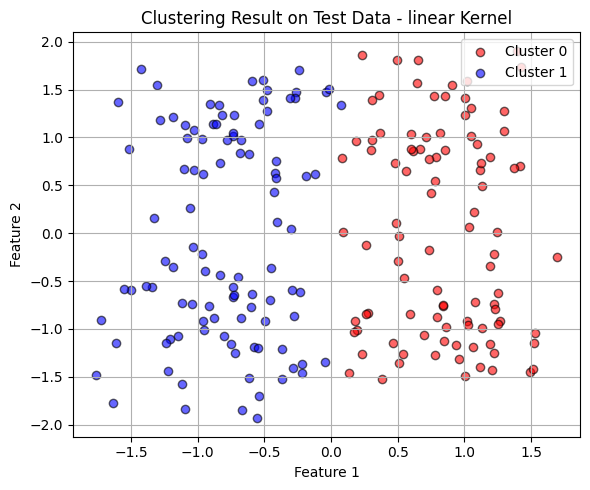

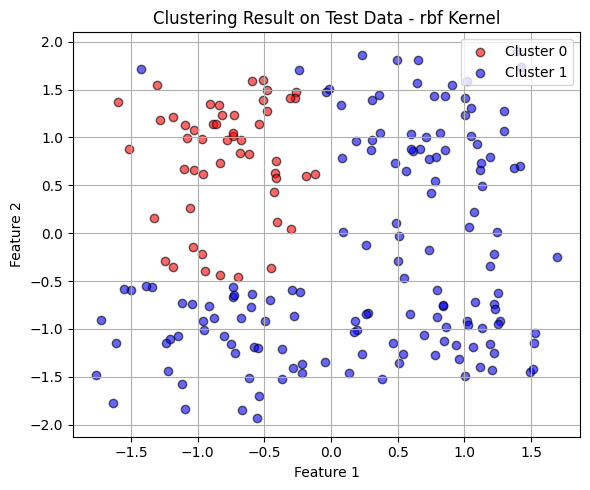

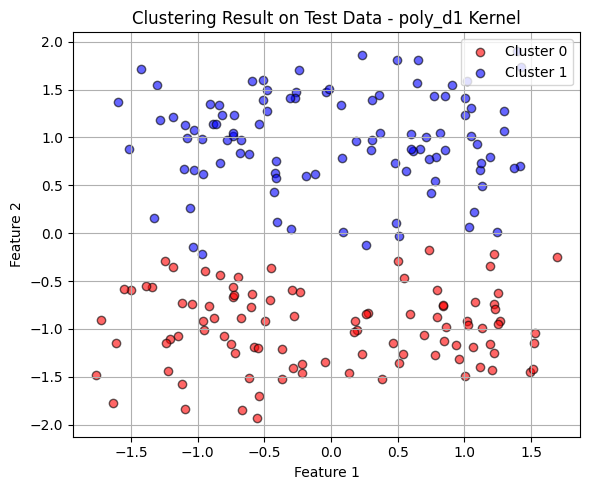

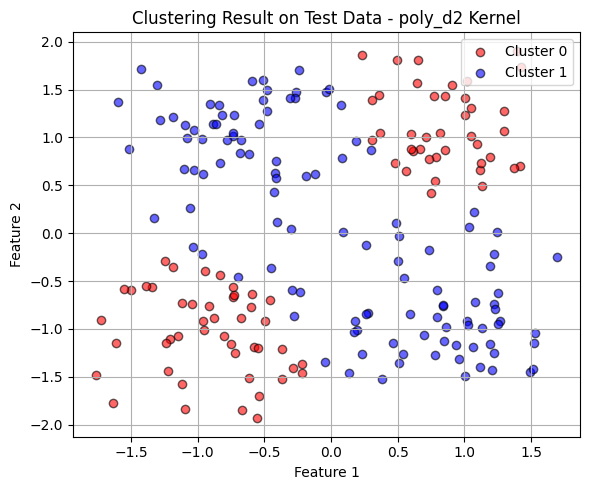

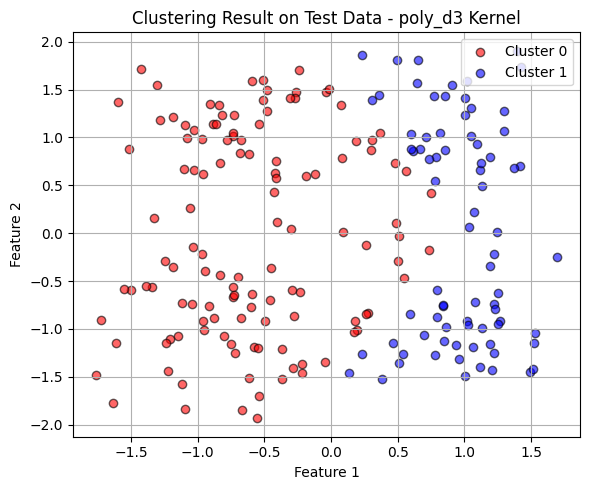

In [59]:
# Visualize clustering results on test data
for name, assign in assign_dict_test.items():
    plt.figure(figsize=(6, 5))

    plt.scatter(X_test[assign == 0, 0], X_test[assign == 0, 1],
                c='red', label='Cluster 0', alpha=0.6, edgecolor='k')
    plt.scatter(X_test[assign == 1, 0], X_test[assign == 1, 1],
                c='blue', label='Cluster 1', alpha=0.6, edgecolor='k')

    plt.title(f'Clustering Result on Test Data - {name} Kernel')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'clusters_test_{name}.png')
    plt.show()


Cell 13:Plot Test F1 Score for Kernel K-Means (Part 2)

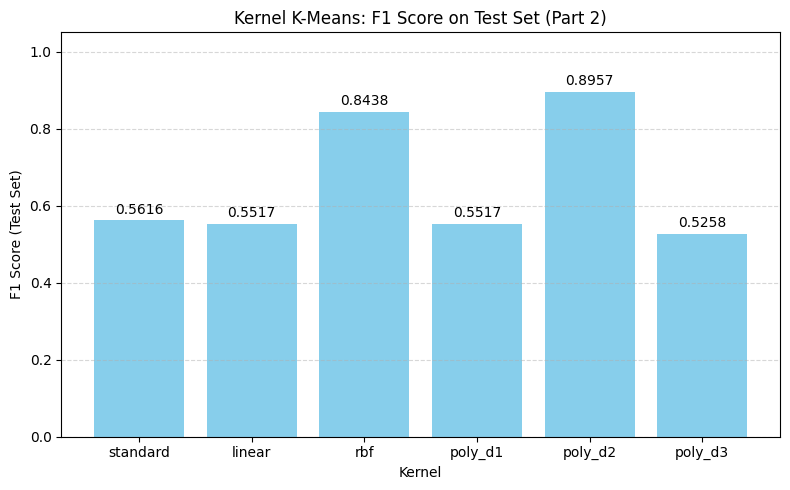

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# === Get kernel names from the test metrics dictionary ===
kernels = list(metrics_test.keys())

# === Compute average F1 score for each kernel ===
test_f1_scores = [np.mean(metrics_test[k]['f1']) for k in kernels]

# === Plotting ===
plt.figure(figsize=(8, 5))
bars = plt.bar(kernels, test_f1_scores, color='skyblue')

# === Annotate each bar with its value ===
for bar, score in zip(bars, test_f1_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0,
             height + 0.01,
             f"{score:.4f}",
             ha='center', va='bottom', fontsize=10)

# === Labels and title ===
plt.ylabel('F1 Score (Test Set)')
plt.xlabel('Kernel')
plt.title('Kernel K-Means: F1 Score on Test Set (Part 2)')
plt.ylim(0, 1.05)  # Set upper limit slightly above 1 for spacing
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# === Show plot ===
plt.show()


#Part 3: Linear Regression with Regularization

Cell 1: Import libraries

In [61]:
# === Imports ===

# Core
import numpy as np
import time

# Plotting
import matplotlib.pyplot as plt

# Data & Preprocessing
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score


Cell 2: Load dataset

In [62]:
from sklearn.datasets import load_diabetes

# === Load the diabetes dataset (UCI) ===
data = load_diabetes()
X = data.data              # Features (442 samples × 10 features)
y = data.target            # Target: disease progression measure

# === Display dataset shape and brief info ===
print("Diabetes dataset loaded.")
print("Feature matrix shape :", X.shape)
print("Target vector shape  :", y.shape)
print("Feature names        :", data.feature_names)
print("Target sample preview:", y[:5])


Diabetes dataset loaded.
Feature matrix shape : (442, 10)
Target vector shape  : (442,)
Feature names        : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target sample preview: [151.  75. 141. 206. 135.]


Cell 3: Define lambda values to tune

In [63]:
# === Define lambda values for regularization tuning ===
# Log-spaced values from 0.0001 to 10 for use in Ridge and Lasso
lambdas = np.linspace(0.001, 1.0, 10)

print("Lambda values to test:", lambdas)

Lambda values to test: [0.001 0.112 0.223 0.334 0.445 0.556 0.667 0.778 0.889 1.   ]


Cell 4: Implement Ordinary Least Squares (OLS)

In [64]:
def ols(X, y):
    """
    Ordinary Least Squares (OLS) regression using closed-form solution.

    Parameters:
        X (ndarray): Feature matrix of shape (N, D)
        y (ndarray): Target vector of shape (N,)

    Returns:
        beta (ndarray): Coefficient vector of shape (D+1,) including bias
    """
    # Add bias term (column of 1s)
    X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])

    # Closed-form solution: β = (XᵀX)⁻¹ Xᵀy
    beta = np.linalg.pinv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
    return beta


 Cell 5: Ridge Regression (L2 Regularization)

In [65]:
def ridge(X, y, lambda_):
    """
    Ridge Regression (L2 Regularization) using closed-form solution.

    Parameters:
        X (ndarray): Feature matrix of shape (N, D)
        y (ndarray): Target vector of shape (N,)
        lambda_ (float): Regularization strength (λ)

    Returns:
        beta (ndarray): Coefficient vector of shape (D+1,) including bias
    """
    # Add bias term
    X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])
    n_features = X_with_bias.shape[1]

    # Identity matrix for regularization, skip regularizing the bias (first element)
    I = np.eye(n_features)
    I[0, 0] = 0  # Do not regularize the bias term

    # Closed-form Ridge: β = (XᵀX + λI)⁻¹ Xᵀy
    beta = np.linalg.pinv(X_with_bias.T @ X_with_bias + lambda_ * I) @ X_with_bias.T @ y
    return beta


Cell 6: Lasso Regression (L1 Regularization)

In [66]:
def soft_threshold(x, lambda_):
    """
    Soft-thresholding operator used in Lasso regression.

    Parameters:
        x : float
        lambda_ : float

    Returns:
        float : thresholded value
    """
    if x > 0 and lambda_ < abs(x):
        return x - lambda_
    elif x < 0 and lambda_ < abs(x):
        return x + lambda_
    else:
        return 0.0


def lasso(X, y, lambda_, max_iter=1000, tol=1e-6):
    """
    Lasso Regression using Coordinate Descent.

    Parameters:
        X : ndarray of shape (n_samples, n_features)
            Feature matrix
        y : ndarray of shape (n_samples,)
            Target vector
        lambda_ : float
            Regularization strength
        max_iter : int
            Maximum number of coordinate descent iterations
        tol : float
            Tolerance for convergence

    Returns:
        beta : ndarray of shape (n_features + 1,)
            Coefficient vector including bias term at index 0
    """
    # Add bias (intercept) term
    X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])
    n_samples, n_features = X_with_bias.shape

    beta = np.zeros(n_features)

    for _ in range(max_iter):
        beta_old = beta.copy()

        # === Update bias (not regularized) ===
        y_pred = X_with_bias @ beta
        residual = y - y_pred + X_with_bias[:, 0] * beta[0]
        beta[0] = np.mean(residual)

        # === Update other coefficients using soft-thresholding ===
        for j in range(1, n_features):
            residual = y - X_with_bias @ beta + X_with_bias[:, j] * beta[j]
            rho = np.dot(X_with_bias[:, j], residual) / n_samples
            beta[j] = soft_threshold(rho, lambda_ / n_samples)

        # === Check convergence ===
        if np.sum((beta - beta_old) ** 2) < tol:
            break

    return beta


Cell 7: Lambda tuning using 5-fold cross-validation

In [75]:
def tune_ridge(X_train, y_train, lambdas, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    avg_mse_list = []

    for lambda_ in lambdas:
        mse_fold = []
        for train_idx, val_idx in kf.split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            beta = ridge(X_tr, y_tr, lambda_)
            X_val_bias = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
            y_pred = X_val_bias @ beta

            mse_fold.append(mean_squared_error(y_val, y_pred))
        avg_mse_list.append(np.mean(mse_fold))

    best_idx = np.argmin(avg_mse_list)
    return lambdas[best_idx]


def tune_lasso(X_train, y_train, lambdas, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    avg_mse_list = []

    for lambda_ in lambdas:
        mse_fold = []
        for train_idx, val_idx in kf.split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            beta = lasso(X_tr, y_tr, lambda_)
            X_val_bias = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
            y_pred = X_val_bias @ beta

            mse_fold.append(mean_squared_error(y_val, y_pred))
        avg_mse_list.append(np.mean(mse_fold))

    best_idx = np.argmin(avg_mse_list)
    return lambdas[best_idx]



Cell 8: Run one experiment

In [76]:
def perform_run(X, y, run_id, standardize=True):
    """
    Execute one full training/testing pipeline run for OLS, Ridge, and Lasso regression models.

    Parameters:
        X : ndarray of shape (n_samples, n_features)
            Feature matrix
        y : ndarray of shape (n_samples,)
            Target vector
        run_id : int
            Random seed for train/test split reproducibility
        standardize : bool
            Whether to apply StandardScaler (zero mean, unit variance)

    Returns:
        dict : A dictionary containing metrics, predictions, and coefficients for all three models
    """

    # === Split the dataset ===
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=run_id
    )

    # === Optionally apply feature standardization ===
    if standardize:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # === Utility: add bias (intercept) term ===
    def add_bias(X):
        return np.hstack([np.ones((X.shape[0], 1)), X])

    # === OLS ===
    start = time.time()
    beta_ols = ols(X_train, y_train)
    y_pred_ols = add_bias(X_test) @ beta_ols
    time_ols = (time.time() - start) * 1000
    mse_ols = mean_squared_error(y_test, y_pred_ols)
    r2_ols = r2_score(y_test, y_pred_ols)

    # === Ridge ===
    start = time.time()
    best_lambda_ridge = tune_ridge(X_train, y_train, lambdas)
    beta_ridge = ridge(X_train, y_train, best_lambda_ridge)
    y_pred_ridge = add_bias(X_test) @ beta_ridge
    time_ridge = (time.time() - start) * 1000
    mse_ridge = mean_squared_error(y_test, y_pred_ridge)
    r2_ridge = r2_score(y_test, y_pred_ridge)

    # === Lasso ===
    start = time.time()
    best_lambda_lasso = tune_lasso(X_train, y_train, lambdas)
    beta_lasso = lasso(X_train, y_train, best_lambda_lasso)
    y_pred_lasso = add_bias(X_test) @ beta_lasso
    time_lasso = (time.time() - start) * 1000
    mse_lasso = mean_squared_error(y_test, y_pred_lasso)
    r2_lasso = r2_score(y_test, y_pred_lasso)

    # === Warn if Lasso over-regularizes ===
    if np.allclose(beta_lasso[1:], 0):
        print(f"Run {run_id}: All Lasso coefficients are zero — try smaller λ (λ = {best_lambda_lasso:.5f})")

    # === Return performance results and predictions ===
    return {
        'ols': {
            'mse': mse_ols, 'r2': r2_ols, 'time': time_ols, 'beta': beta_ols
        },
        'ridge': {
            'mse': mse_ridge, 'r2': r2_ridge, 'time': time_ridge,
            'beta': beta_ridge, 'lambda': best_lambda_ridge
        },
        'lasso': {
            'mse': mse_lasso, 'r2': r2_lasso, 'time': time_lasso,
            'beta': beta_lasso, 'lambda': best_lambda_lasso
        },
        'y_test': y_test,
        'y_pred_ols': y_pred_ols,
        'y_pred_ridge': y_pred_ridge,
        'y_pred_lasso': y_pred_lasso
    }


Cell 9: Run all experiments

In [78]:
# === Run 10 experiments with and without standardization ===
n_runs = 10

print("Running experiments WITH standardization...")
results_with_std = [
    perform_run(X, y, run_id=i, standardize=True) for i in range(n_runs)
]

print("\nRunning experiments WITHOUT standardization...")
results_without_std = [
    perform_run(X, y, run_id=i, standardize=False) for i in range(n_runs)
]

print("\nAll runs completed.")


Running experiments WITH standardization...

Running experiments WITHOUT standardization...

All runs completed.


Cell 10: Compute statistics

In [79]:
def compute_stats(results, model):
    """
    Compute average and standard deviation of metrics for a given model over multiple runs.

    Parameters:
        results : list of dict
            List of results from multiple perform_run() calls
        model : str
            One of {'ols', 'ridge', 'lasso'}

    Returns:
        dict : Aggregated metrics:
            - mse_mean, mse_std
            - r2_mean, r2_std
            - time_mean
    """
    mse_values = [r[model]['mse'] for r in results]
    r2_values = [r[model]['r2'] for r in results]
    time_values = [r[model]['time'] for r in results]

    return {
        'mse_mean': np.mean(mse_values),
        'mse_std': np.std(mse_values),
        'r2_mean': np.mean(r2_values),
        'r2_std': np.std(r2_values),
        'time_mean': np.mean(time_values)
    }

# === Aggregate stats for all models (OLS, Ridge, Lasso) ===
stats_with_std = {
    model: compute_stats(results_with_std, model)
    for model in ['ols', 'ridge', 'lasso']
}

stats_without_std = {
    model: compute_stats(results_without_std, model)
    for model in ['ols', 'ridge', 'lasso']
}


Cell 11: Visualization (scatter plots)

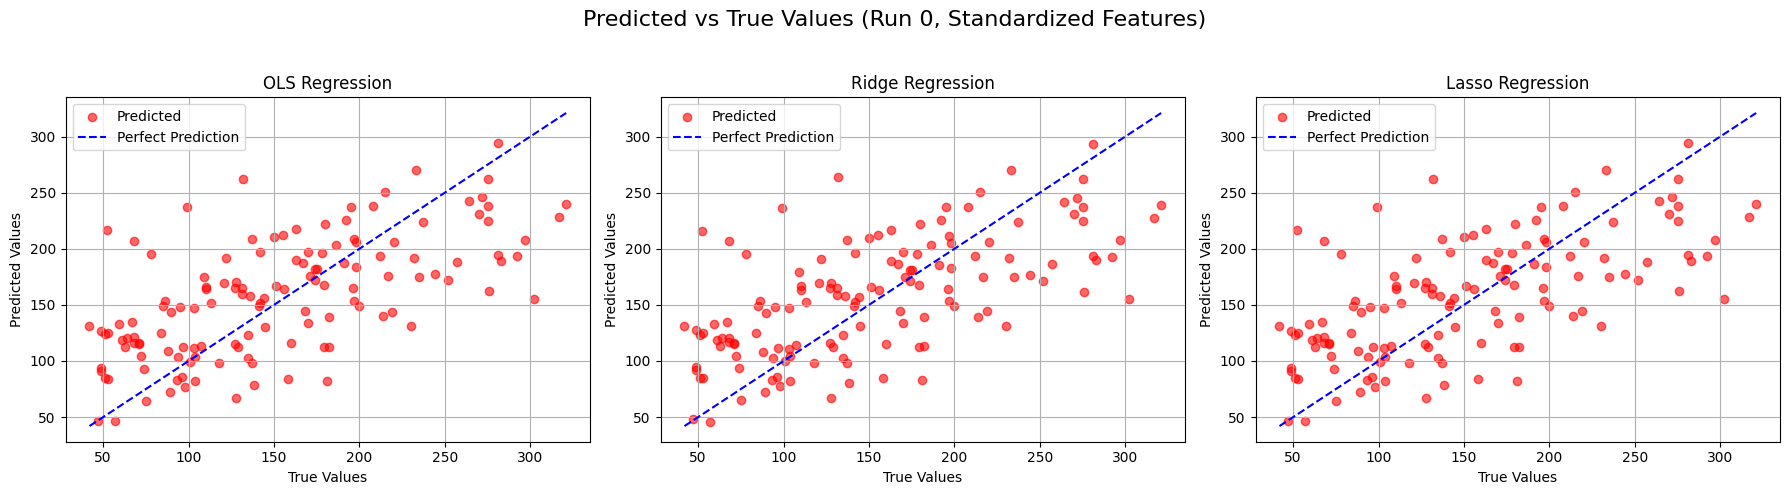

In [80]:
# === Visual comparison of predicted vs true values (Run 0, Standardized) ===
res = results_with_std[0]

plt.figure(figsize=(18, 5))

# === OLS ===
plt.subplot(1, 3, 1)
plt.scatter(res['y_test'], res['y_pred_ols'], color='red', alpha=0.6, label='Predicted')
plt.plot([min(res['y_test']), max(res['y_test'])], [min(res['y_test']), max(res['y_test'])],
         color='blue', linestyle='--', label='Perfect Prediction')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('OLS Regression')
plt.legend()
plt.grid(True)

# === Ridge ===
plt.subplot(1, 3, 2)
plt.scatter(res['y_test'], res['y_pred_ridge'], color='red', alpha=0.6, label='Predicted')
plt.plot([min(res['y_test']), max(res['y_test'])], [min(res['y_test']), max(res['y_test'])],
         color='blue', linestyle='--', label='Perfect Prediction')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Ridge Regression')
plt.legend()
plt.grid(True)

# === Lasso ===
plt.subplot(1, 3, 3)
plt.scatter(res['y_test'], res['y_pred_lasso'], color='red', alpha=0.6, label='Predicted')
plt.plot([min(res['y_test']), max(res['y_test'])], [min(res['y_test']), max(res['y_test'])],
         color='blue', linestyle='--', label='Perfect Prediction')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Lasso Regression')
plt.legend()
plt.grid(True)

plt.suptitle("Predicted vs True Values (Run 0, Standardized Features)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Cell 12: Lasso coefficient plot

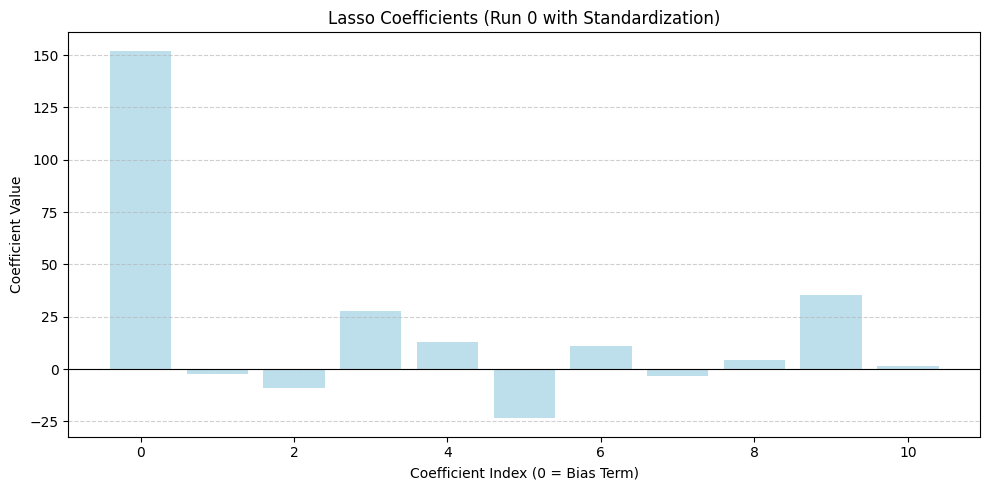

In [81]:
# === Lasso Coefficients Plot: Run 0 (Standardized Features) ===
lasso_beta = res['lasso']['beta']

plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(lasso_beta)), lasso_beta, color='lightblue', alpha=0.8)

plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Index (0 = Bias Term)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficients (Run 0 with Standardization)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Optional: Highlight zero coefficients
for bar in bars[1:]:  # skip bias
    if abs(bar.get_height()) < 1e-5:
        bar.set_color('gray')

plt.tight_layout()
plt.show()


Cell 13: Print final results

In [82]:
def print_stats(stats_dict, title):
    """
    Pretty print summary statistics for each model.
    """
    print(f"\n{'='*75}")
    print(f" {title}")
    print(f"{'-'*75}")
    print(f"{'Model':<10} {'MSE Mean ± Std':<25} {'R² Mean ± Std':<25} {'Time (ms)':<10}")
    print(f"{'-'*75}")

    for model, stats in stats_dict.items():
        mse = f"{stats['mse_mean']:.4f} ± {stats['mse_std']:.4f}"
        r2 = f"{stats['r2_mean']:.4f} ± {stats['r2_std']:.4f}"
        time_ms = f"{stats['time_mean']:.2f}"
        print(f"{model.upper():<10} {mse:<25} {r2:<25} {time_ms:<10}")

    print(f"{'='*75}")

# Display results
print_stats(stats_with_std, "Results WITH Feature Standardization")
print_stats(stats_without_std, "Results WITHOUT Feature Standardization")



 Results WITH Feature Standardization
---------------------------------------------------------------------------
Model      MSE Mean ± Std            R² Mean ± Std             Time (ms) 
---------------------------------------------------------------------------
OLS        2914.6772 ± 243.4016      0.4764 ± 0.0530           0.38      
RIDGE      2910.9148 ± 245.0062      0.4770 ± 0.0534           56.05     
LASSO      2914.4781 ± 243.7645      0.4764 ± 0.0530           4789.72   

 Results WITHOUT Feature Standardization
---------------------------------------------------------------------------
Model      MSE Mean ± Std            R² Mean ± Std             Time (ms) 
---------------------------------------------------------------------------
OLS        2914.6772 ± 243.4016      0.4764 ± 0.0530           0.38      
RIDGE      2918.6354 ± 253.8788      0.4760 ± 0.0510           52.29     
LASSO      5578.4752 ± 398.6560      0.0018 ± 0.0045           74.34     


Cell 14: Visual comparison of MSE and R² between models

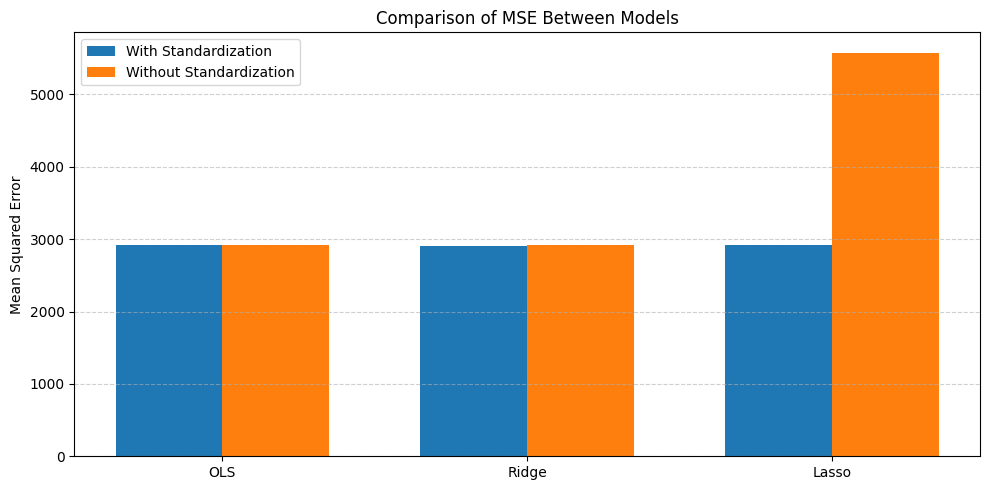

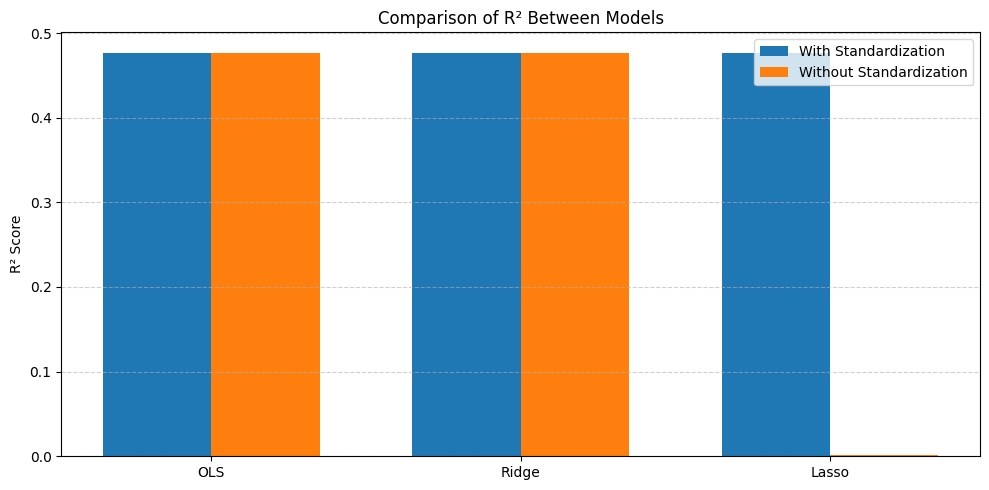

In [83]:
# --- Prepare data for comparison ---
import matplotlib.pyplot as plt

models = ['OLS', 'Ridge', 'Lasso']
mse_with = [stats_with_std[m.lower()]['mse_mean'] for m in models]
mse_without = [stats_without_std[m.lower()]['mse_mean'] for m in models]
r2_with = [stats_with_std[m.lower()]['r2_mean'] for m in models]
r2_without = [stats_without_std[m.lower()]['r2_mean'] for m in models]

x = np.arange(len(models))
width = 0.35  # Bar width

# --- Plot MSE Comparison ---
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, mse_with, width, label='With Standardization')
plt.bar(x + width/2, mse_without, width, label='Without Standardization')
plt.xticks(x, models)
plt.ylabel('Mean Squared Error')
plt.title('Comparison of MSE Between Models')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Plot R² Comparison ---
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, r2_with, width, label='With Standardization')
plt.bar(x + width/2, r2_without, width, label='Without Standardization')
plt.xticks(x, models)
plt.ylabel('R² Score')
plt.title('Comparison of R² Between Models')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
